In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.tree import DecisionTreeClassifier, DecisionTreeRegressor, plot_tree
from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

In [27]:
df = pd.read_csv('heart.csv')
print("First few records:")
print(df.head())

print("\nColumns in the dataset:")
print(df.columns)

First few records:
   age  sex  cp  trestbps  chol  fbs  restecg  thalach  exang  oldpeak  slope  \
0   69    1   0       160   234    1        2      131      0      0.1      1   
1   69    0   0       140   239    0        0      151      0      1.8      0   
2   66    0   0       150   226    0        0      114      0      2.6      2   
3   65    1   0       138   282    1        2      174      0      1.4      1   
4   64    1   0       110   211    0        2      144      1      1.8      1   

   ca  thal  condition  
0   1     0          0  
1   2     0          0  
2   0     0          0  
3   1     0          1  
4   0     0          0  

Columns in the dataset:
Index(['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach',
       'exang', 'oldpeak', 'slope', 'ca', 'thal', 'condition'],
      dtype='object')


CLASSIFICATION

In [30]:
X_cls = df.drop('condition', axis=1)
y_cls = df['condition']

In [32]:
X_train_cls, X_test_cls, y_train_cls, y_test_cls = train_test_split(X_cls, y_cls, test_size=0.2, random_state=42)

In [34]:
tree_cls = DecisionTreeClassifier(random_state=42)
tree_cls.fit(X_train_cls, y_train_cls)

DecisionTreeClassifier(random_state=42)

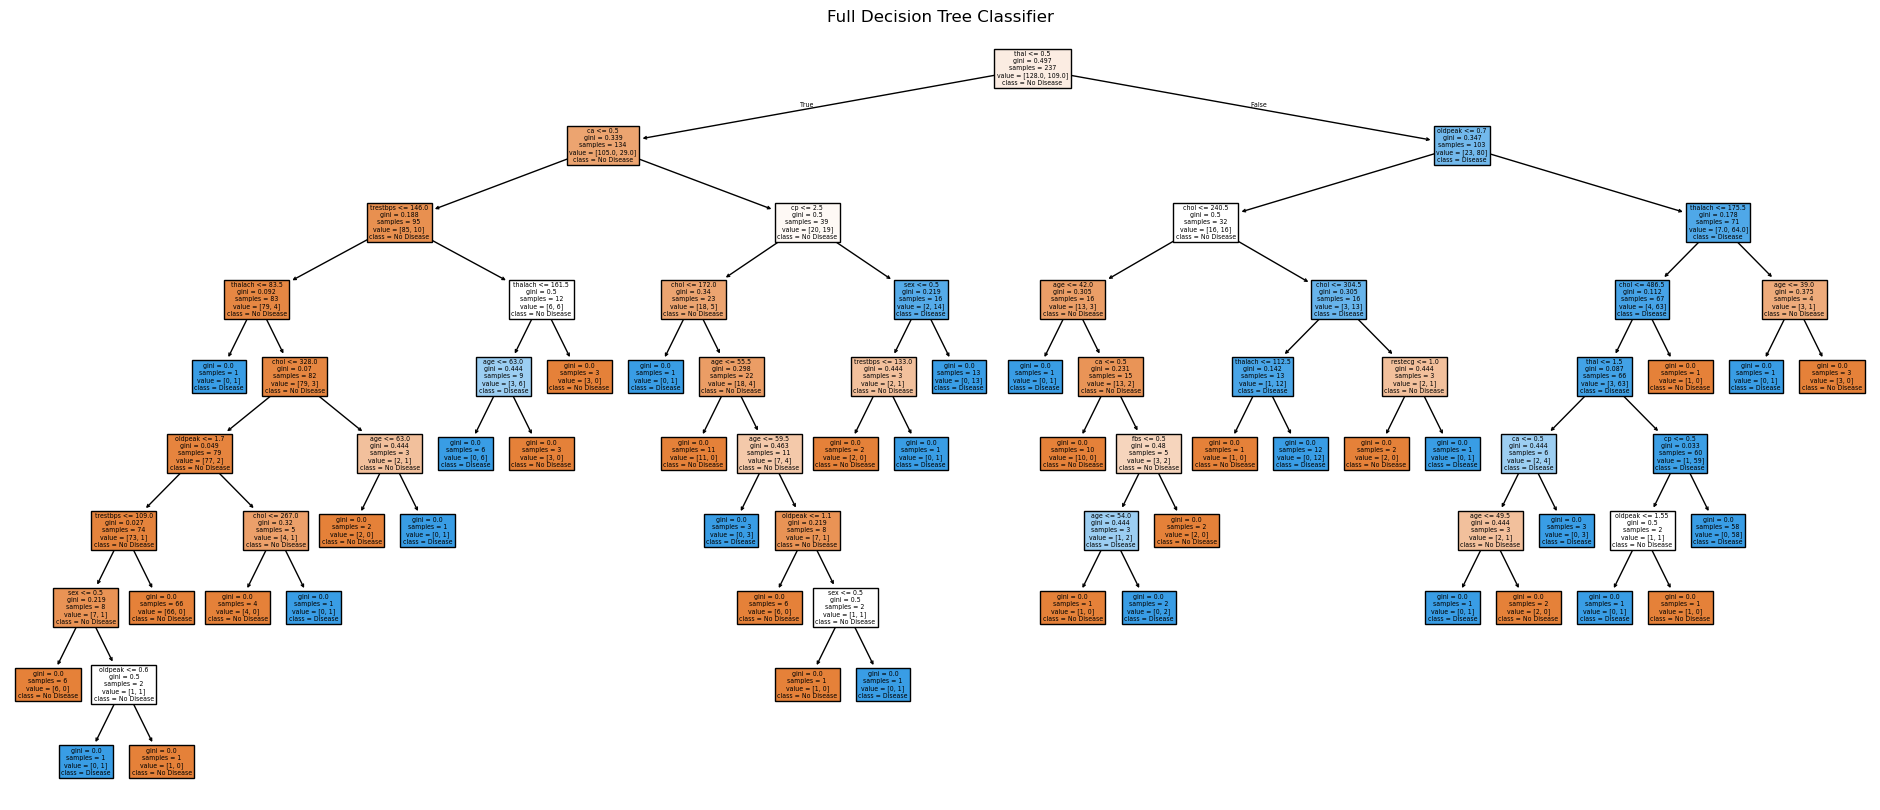

In [36]:
plt.figure(figsize=(24, 10))
plot_tree(tree_cls, filled=True, feature_names=X_cls.columns, class_names=["No Disease", "Disease"])
plt.title("Full Decision Tree Classifier")
plt.show()

In [38]:
y_pred_tree_cls = tree_cls.predict(X_test_cls)
print("Full Tree Accuracy:", accuracy_score(y_test_cls, y_pred_tree_cls))

Full Tree Accuracy: 0.7666666666666667


In [42]:
tree_pruned = DecisionTreeClassifier(max_depth=4, random_state=42)
tree_pruned.fit(X_train_cls, y_train_cls)
y_pred_pruned = tree_pruned.predict(X_test_cls)
print("Pruned Tree Accuracy:", accuracy_score(y_test_cls, y_pred_pruned))

Pruned Tree Accuracy: 0.65


In [44]:
forest_cls = RandomForestClassifier(n_estimators=100, random_state=42)
forest_cls.fit(X_train_cls, y_train_cls)
y_pred_forest_cls = forest_cls.predict(X_test_cls)
print("Random Forest Accuracy:", accuracy_score(y_test_cls, y_pred_forest_cls))

Random Forest Accuracy: 0.7


In [46]:
print(classification_report(y_test_cls, y_pred_forest_cls, target_names=["No Disease", "Disease"]))

              precision    recall  f1-score   support

  No Disease       0.73      0.69      0.71        32
     Disease       0.67      0.71      0.69        28

    accuracy                           0.70        60
   macro avg       0.70      0.70      0.70        60
weighted avg       0.70      0.70      0.70        60



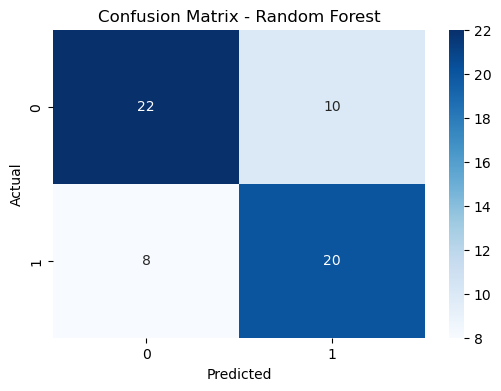

In [48]:
plt.figure(figsize=(6, 4))
sns.heatmap(confusion_matrix(y_test_cls, y_pred_forest_cls), annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

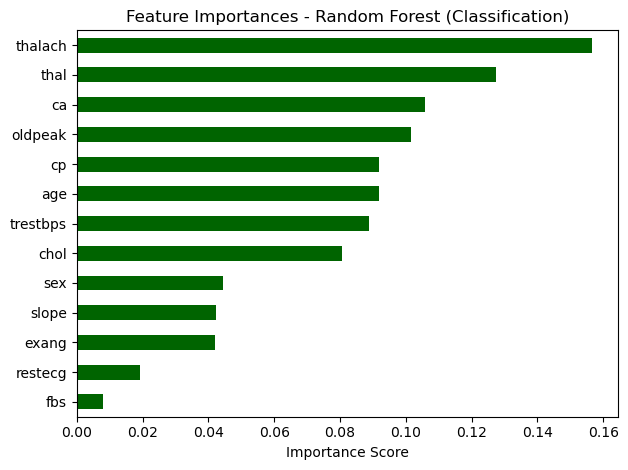

In [50]:
feat_imp_cls = pd.Series(forest_cls.feature_importances_, index=X_cls.columns).sort_values()
feat_imp_cls.plot(kind='barh', color='darkgreen')
plt.title("Feature Importances - Random Forest (Classification)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

In [52]:
cv_tree = cross_val_score(tree_pruned, X_cls, y_cls, cv=5).mean()
cv_rf = cross_val_score(forest_cls, X_cls, y_cls, cv=5).mean()

print(f"CV Score (Pruned Tree): {cv_tree:.4f}")
print(f"CV Score (Random Forest): {cv_rf:.4f}")

CV Score (Pruned Tree): 0.6805
CV Score (Random Forest): 0.7410


REGRESSION

In [55]:
X_reg = df.drop('chol', axis=1)
y_reg = df['chol']

In [57]:
X_train_reg, X_test_reg, y_train_reg, y_test_reg = train_test_split(X_reg, y_reg, test_size=0.2, random_state=42)

In [59]:
tree_reg = DecisionTreeRegressor(random_state=42)
tree_reg.fit(X_train_reg, y_train_reg)
y_pred_tree_reg = tree_reg.predict(X_test_reg)

In [61]:
forest_reg = RandomForestRegressor(n_estimators=100, random_state=42)
forest_reg.fit(X_train_reg, y_train_reg)
y_pred_forest_reg = forest_reg.predict(X_test_reg)

In [63]:
def evaluate_regression(y_true, y_pred, model_name):
    print(f"\n{model_name} Metrics:")
    print(f" - MAE : {mean_absolute_error(y_true, y_pred):.2f}")
    print(f" - MSE : {mean_squared_error(y_true, y_pred):.2f}")
    print(f" - R²  : {r2_score(y_true, y_pred):.4f}")

evaluate_regression(y_test_reg, y_pred_tree_reg, "Decision Tree Regressor")
evaluate_regression(y_test_reg, y_pred_forest_reg, "Random Forest Regressor")


Decision Tree Regressor Metrics:
 - MAE : 46.28
 - MSE : 3396.95
 - R²  : -0.7868

Random Forest Regressor Metrics:
 - MAE : 36.45
 - MSE : 2024.21
 - R²  : -0.0647


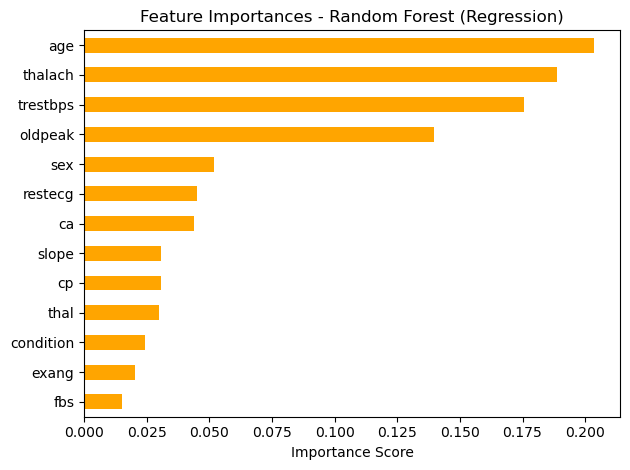

In [65]:
feat_imp_reg = pd.Series(forest_reg.feature_importances_, index=X_reg.columns).sort_values()
feat_imp_reg.plot(kind='barh', color='orange')
plt.title("Feature Importances - Random Forest (Regression)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()